# 03 Data Preparation

In CRISP-DM Phase 3 wird aus dem rohen Datensatz ein sauberes, reproduzierbares Feature-Set aufgebaut,
das in Phase 4 (Modellierung) direkt eingesetzt werden kann.
Ziel dieses Notebooks ist keine Modellauswahl, sondern die Herstellung
methodisch korrekter Traings- und Testmengen sowie die Vorbereitung aller Features.

**Struktur:**
1. Setup
2. Datensatz laden
3. Stratifizierter Train/Test-Split
4. Feature-Typen definieren
5. Preprocessing-Pipeline
6. Transformierten Datensatz speichern

## 1. Setup

Alle Bibliotheken werden hier zentral importiert. Der globale Seed wird einmalig
festgelegt und in allen randomisierten Schritten (Split, SMOTE, Modelle) konsistent
verwendet — so ist das gesamte Notebook mit einem einzigen Wert reproduzierbar.

In [1]:
import importlib, subprocess, sys
for pkg in ['ucimlrepo', 'imbalanced-learn']:
    if importlib.util.find_spec(pkg.replace('-', '_')) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split

SEED = 42
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))


## 2. Datensatz laden

Der Datensatz wird erneut direkt aus dem UCI ML Repository geladen (ID 891).
Das stellt sicher, dass dieses Notebook unabhängig von Zwischenspeicherständen
aus Notebook 02 lauffähig ist und stets auf der Originalversion operiert.

In [2]:
dataset = fetch_ucirepo(id=891)
X = dataset.data.features.copy()
y = dataset.data.targets.squeeze().copy()

print(f"Features: {X.shape}")
print(f"Target:   {y.shape}")
print(f"Klassen:  {y.value_counts().to_dict()}")

Features: (253680, 21)
Target:   (253680,)
Klassen:  {0: 218334, 1: 35346}


## 3. Stratifizierter Train/Test-Split

Der Split wird als allererster Schritt vor jeder weiteren Transformation durchgeführt.
Das ist zwingend erforderlich, um Data Leakage zu verhindern: Skalierung, Imputation
und Oversampling werden ausschließlich auf dem Trainingsfold angepasst und dürfen
keinerlei Information aus dem Testfold einbeziehen.

**Warum stratifiziert?**
Bei einer Klassenverteilung von ca. 86 / 14 kann ein zufälliger Split die Prävalenz
in Trainings- und Testmenge systematisch verschieben — insbesondere in kleineren
Splits. Stratifizierung garantiert, dass beide Mengen dieselbe Klassenverteilung wie
der Gesamtdatensatz aufweisen.

**Warum 80/20?**
Bei ~253 680 Samples liefert ein 20-%-Testset bereits ~50 000 Beobachtungen —
ausreichend für stabile Metriken auch in Subgruppenanalysen. 80 % Trainingsdaten
stellen sicher, dass seltene Muster (positive Klasse, Subgruppen) gut repräsentiert sind.

**Testset-Verwendung:** Das Testset wird nach diesem Split eingefroren. Es wird
ausschließlich für die einmalige finale Modell-Evaluation genutzt — nicht für
Modellauswahl, Feature-Auswahl, Hyperparameteroptimierung oder Threshold-Wahl.
Jede dieser Nutzungen würde Data Leakage erzeugen und die berichtete Testperformance
verzerren.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

print(f"Train: {X_train.shape[0]:>7} Samples")
print(f"Test:  {X_test.shape[0]:>7} Samples")
print()
print("Target-Mean (Prävalenz positive Klasse):")
print(f"  Gesamt: {y.mean():.4f}")
print(f"  Train:  {y_train.mean():.4f}")
print(f"  Test:   {y_test.mean():.4f}")

# Absolute Zahlen pro Klasse
print("\nKlassenverteilung absolut:")
print(f"  Train — 0: {(y_train==0).sum():>6,}  1: {(y_train==1).sum():>5,}")
print(f"  Test  — 0: {(y_test==0).sum():>6,}  1: {(y_test==1).sum():>5,}")

Train:  202944 Samples
Test:    50736 Samples

Target-Mean (Prävalenz positive Klasse):
  Gesamt: 0.1393
  Train:  0.1393
  Test:   0.1393

Klassenverteilung absolut:
  Train — 0: 174,667  1: 28,277
  Test  — 0: 43,667  1: 7,069


## 4. Feature-Typen definieren

Die Features werden entsprechend ihrer semantischen Bedeutung gruppiert. Obwohl alle
Variablen technisch als Integer gespeichert sind, unterscheiden sie sich inhaltlich deutlich:
Einige Variablen sind binäre Indikatoren, andere sind ordinal kodierte Kategorien,
zwei Variablen zählen die Anzahl gesundheitlich eingeschränkter Tage und BMI ist das
einzige kontinuierlich interpretierbare numerische Feature.

Diese Gruppierung ist wichtig, weil verschiedene Modelltypen unterschiedlich auf
Feature-Skalierung, Ausreißer und kodierte Kategorien reagieren. Für eine erste
Baseline werden die Features möglichst nah an ihrer Originalform belassen. Dadurch
entsteht ein unveränderter Referenzpunkt, gegen den spätere Feature-Engineering-
Varianten verglichen werden können.

Die in Notebook 02 identifizierten möglichen Transformationen — insbesondere
BMI-Capping, Hurdle-Encoding für MentHlth und PhysHlth sowie Composite Features —
werden daher nicht sofort als finale Entscheidungen übernommen, sondern in den
folgenden Experimenten systematisch getestet. Ob eine Transformation beibehalten wird,
entscheidet sich anhand der Cross-Validation-Performance und nicht allein anhand der
explorativen Analyse.

In [4]:
BINARY_COLS = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex",
]

ORDINAL_COLS = [
    "GenHlth",
    "Age",
    "Education",
    "Income",
]

COUNT_COLS = [
    "MentHlth",
    "PhysHlth",
]

NUMERIC_COLS = [
    "BMI",
]

ALL_FEATURES = BINARY_COLS + ORDINAL_COLS + COUNT_COLS + NUMERIC_COLS

print(f"Anzahl definierter Features: {len(ALL_FEATURES)}")
print(f"Anzahl Features im Datensatz: {X_train.shape[1]}")

print("\nNicht definierte Spalten:")
print(set(X_train.columns) - set(ALL_FEATURES))

print("\nDefiniert, aber nicht im Datensatz:")
print(set(ALL_FEATURES) - set(X_train.columns))

Anzahl definierter Features: 21
Anzahl Features im Datensatz: 21

Nicht definierte Spalten:
set()

Definiert, aber nicht im Datensatz:
set()


## 5. Transformationsfunktionen definieren

Die Transformationsfunktionen `cap_bmi`, `categorize_bmi` und `hurdle_encode`
sind in `src/utils.py` definiert und werden hier importiert. Dadurch können
NB05 (Feature Engineering) und zukünftige Notebooks dieselben Implementierungen
ohne Redundanz nutzen.

Alle Funktionen arbeiten auf einer Kopie des DataFrames und geben einen
neuen DataFrame zurück.

### 5.1 BMI — Variante 1: Capping

Extremwerte werden auf das Intervall [18, 50] begrenzt (Winsorizing).
Keine Zeilen werden entfernt — Werte außerhalb der Grenzen werden
auf den jeweiligen Grenzwert gesetzt.

Begründung (Notebook 02, Abschnitt 9.2): Die Perzentil-Methode P1/P99
liefert die Grenzen 18 und 50. Diese stimmen mit klinischen WHO-Schwellen
überein: BMI < 18,5 entspricht Untergewicht, BMI ≥ 50 Super-Adipositas.

In [5]:
from src.utils import cap_bmi, categorize_bmi, hurdle_encode
print('Transformationsfunktionen aus src.utils importiert.')

Transformationsfunktionen aus src.utils importiert.


### 5.2 BMI — Variante 2: Kategorisierung

BMI wird in sieben klinische Kategorien überführt (0–6).
Aus dem numerischen Feature wird damit ein ordinales — der absolute
Zahlenwert verliert seine Bedeutung, die Reihenfolge bleibt erhalten.

Quelle: Dietrich-Bonhoeffer-Klinikum Adipositaszentrum
https://dbknb.de/zentren/adipositaszentrum/adipositas

In Notebook 04 wird verglichen ob Capping oder Kategorisierung
eine höhere PR-AUC liefert.

In [6]:
# categorize_bmi wird aus src.utils importiert (siehe Zelle oben).

### 5.3 Hurdle-Encoding — MentHlth und PhysHlth

Für jede Count-Variable werden zwei neue Spalten erstellt:
- `_any`  — Binärindikator: war überhaupt ein Tag betroffen? (0/1)
- `_days` — Anzahl der betroffenen Tage (Originalwert)

Die Originalspalte wird danach entfernt.

Begründung (Notebook 02, Abschnitt 6.3 und 9.1): Beide Variablen sind
stark zero-inflated (MentHlth 69 %, PhysHlth 63 % Nullen). Ein einzelner
numerischer Wert vermischt zwei inhaltlich verschiedene Informationen —
ob überhaupt eine Beeinträchtigung vorliegt und wie stark sie ist.
Das Hurdle-Encoding trennt diese Anteile explizit.

In [7]:
# hurdle_encode wird aus src.utils importiert (siehe Zelle oben).

## 6. Sanity-Check der Transformationsfunktionen

Bevor die Funktionen in eine Pipeline eingebaut werden, wird ihr Verhalten
an kleinen Demonstrationsbeispielen überprüft. Dabei werden die Originaldaten
**nicht verändert** — alle Transformationen werden nur zu Prüfzwecken auf
temporäre Kopien angewendet.

Drei Checks werden durchgeführt:
1. **BMI-Capping:** Histogramm vor und nach `cap_bmi` zeigt, wie Extremwerte
   gekappt werden, ohne den Kernbereich der Verteilung zu berühren.
2. **BMI-Kategorisierung:** Balkendiagramm der Kategorienhäufigkeiten nach
   `categorize_bmi` prüft, ob die klinischen Grenzen korrekt angewendet werden
   und alle sieben Klassen (0–6) vorhanden sind.
3. **Hurdle-Encoding:** Die ersten Zeilen der neuen Spalten bestätigen, dass
   `_any` und `_days` korrekt aus den Originalwerten abgeleitet werden.

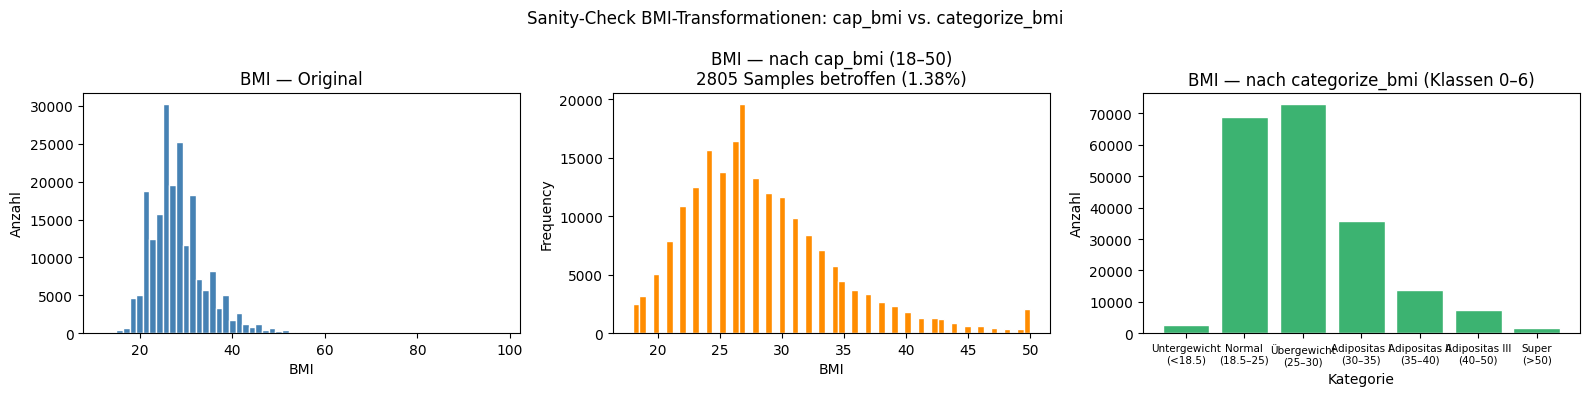

Min/Max vor Capping:  12.0 / 98.0
Min/Max nach Capping: 18.0 / 50.0

Kategorienhäufigkeiten nach categorize_bmi:
BMI_cat
0 — Untergewicht (<18.5)       2506
1 — Normal (18.5–25)          68908
2 — Übergewicht (25–30)       72949
3 — Adipositas I (30–35)      35576
4 — Adipositas II (35–40)     13828
5 — Adipositas III (40–50)     7439
6 — Super (>50)                1738


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: BMI original
X_train["BMI"].plot.hist(bins=60, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("BMI — Original")
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Anzahl")

# Plot 2: BMI nach cap_bmi
X_capped = cap_bmi(X_train)
X_capped["BMI_capped"].plot.hist(bins=60, ax=axes[1], color="darkorange", edgecolor="white")
n_affected = ((X_train["BMI"] < 18) | (X_train["BMI"] > 50)).sum()
axes[1].set_title(
    f"BMI — nach cap_bmi (18–50)\n{n_affected} Samples betroffen ({n_affected/len(X_train):.2%})"
)
axes[1].set_xlabel("BMI")

# Plot 3: BMI nach categorize_bmi
X_cat = categorize_bmi(X_train)
cat_labels = {
    0: "Untergewicht\n(<18.5)",
    1: "Normal\n(18.5–25)",
    2: "Übergewicht\n(25–30)",
    3: "Adipositas I\n(30–35)",
    4: "Adipositas II\n(35–40)",
    5: "Adipositas III\n(40–50)",
    6: "Super\n(>50)",
}
counts = X_cat["BMI_cat"].value_counts().sort_index()
axes[2].bar(
    [cat_labels[i] for i in counts.index],
    counts.values,
    color="mediumseagreen",
    edgecolor="white",
)
axes[2].set_title("BMI — nach categorize_bmi (Klassen 0–6)")
axes[2].set_xlabel("Kategorie")
axes[2].set_ylabel("Anzahl")
axes[2].tick_params(axis="x", labelsize=7.5)

fig.suptitle(
    "Sanity-Check BMI-Transformationen: cap_bmi vs. categorize_bmi",
    fontsize=12,
)
plt.tight_layout()
plt.show()

print(f"Min/Max vor Capping:  {X_train['BMI'].min():.1f} / {X_train['BMI'].max():.1f}")
print(f"Min/Max nach Capping: {X_capped['BMI_capped'].min():.1f} / {X_capped['BMI_capped'].max():.1f}")
print(f"\nKategorienhäufigkeiten nach categorize_bmi:")
print(counts.rename(index=lambda i: f"{i} — {cat_labels[i].replace(chr(10), ' ')}").to_string())

In [9]:
X_hurdle = hurdle_encode(X_train)

hurdle_cols = ["MentHlth_any", "MentHlth_days", "PhysHlth_any", "PhysHlth_days"]
print("Neue Spalten nach hurdle_encode:")
print(X_hurdle[hurdle_cols].head(10).to_string(index=True))

print(f"\nOriginal-Spalten entfernt: {set(['MentHlth','PhysHlth']) - set(X_hurdle.columns)}")
print(f"Neue Spalten hinzugefügt:  {set(hurdle_cols) & set(X_hurdle.columns)}")
print(f"\nSpaltenzahl vorher: {X_train.shape[1]}  |  nachher: {X_hurdle.shape[1]}")

# Kurze Plausibilitätsprüfung: _any stimmt mit >0 überein
assert (X_hurdle["MentHlth_any"] == (X_hurdle["MentHlth_days"] > 0)).all(), \
    "MentHlth_any stimmt nicht mit MentHlth_days > 0 überein!"
assert (X_hurdle["PhysHlth_any"] == (X_hurdle["PhysHlth_days"] > 0)).all(), \
    "PhysHlth_any stimmt nicht mit PhysHlth_days > 0 überein!"
print("\nAssertion bestanden: _any-Flags konsistent mit _days-Werten.")

Neue Spalten nach hurdle_encode:
        MentHlth_any  MentHlth_days  PhysHlth_any  PhysHlth_days
153147             0              0             0              0
176137             0              0             0              0
175578             0              0             0              0
177887             0              0             0              0
182143             1             30             1             30
184279             0              0             0              0
11256              0              0             0              0
136661             1              3             1              1
243608             1             10             1             15
101366             0              0             1              3

Original-Spalten entfernt: {'PhysHlth', 'MentHlth'}
Neue Spalten hinzugefügt:  {'PhysHlth_days', 'MentHlth_days', 'MentHlth_any', 'PhysHlth_any'}

Spaltenzahl vorher: 21  |  nachher: 23

Assertion bestanden: _any-Flags konsistent mit _days-Werten.


## 7. Split & Metadaten speichern

`X_train`, `X_test`, `y_train` und `y_test` werden in `data/processed/` persistiert,
damit Notebook 04 direkt darauf aufbauen kann ohne den Split neu auszuführen.
Die Feature-Typ-Listen werden als JSON gespeichert, sodass Pipeline-Konstruktionen
in späteren Notebooks die Spaltengruppierungen ohne Redundanz übernehmen können.

Gespeichert werden ausschließlich die ungekürzte Traings- und Testmenge im
Originalformat des Splits. Die temporären Prüf-Kopien `X_capped`, `X_cat` und
`X_hurdle` werden nicht persistiert — sie dienten nur der Verifikation der
Transformationsfunktionen in Abschnitt 6.

In [10]:
import json
from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

# Split-Daten
X_train.to_parquet(processed_dir / "X_train.parquet", index=True)
X_test.to_parquet(processed_dir / "X_test.parquet", index=True)
y_train.to_frame().to_parquet(processed_dir / "y_train.parquet", index=True)
y_test.to_frame().to_parquet(processed_dir / "y_test.parquet", index=True)

# Feature-Typ-Metadaten
feature_meta = {
    "binary_cols":  BINARY_COLS,
    "ordinal_cols": ORDINAL_COLS,
    "count_cols":   COUNT_COLS,
    "numeric_cols": NUMERIC_COLS,
    "all_features": ALL_FEATURES,
    "seed":         SEED,
}
with open(processed_dir / "feature_meta.json", "w") as f:
    json.dump(feature_meta, f, indent=2)

print("Gespeichert unter", processed_dir.resolve())
print(f"  X_train.parquet  — {X_train.shape}")
print(f"  X_test.parquet   — {X_test.shape}")
print(f"  y_train.parquet  — {y_train.shape}")
print(f"  y_test.parquet   — {y_test.shape}")
print(f"  feature_meta.json — {len(feature_meta)} Einträge")

Gespeichert unter C:\Users\hashe\Diabetes-Prediction-Hasher\data\processed
  X_train.parquet  — (202944, 21)
  X_test.parquet   — (50736, 21)
  y_train.parquet  — (202944,)
  y_test.parquet   — (50736,)
  feature_meta.json — 6 Einträge
